<a href="https://colab.research.google.com/github/shlok-dhital/6CS012-AI-and-Machine-Learning/blob/main/ShlokDhital_2407091_Worksheet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
from pathlib import Path
import random
from PIL import Image
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

#Task 1: Data Understanding and Visualization

## Load and view image

In [5]:
base_path = Path("/content/drive/MyDrive/AI - ShlokDhital/FruitinAmazon/train")

subdirs = [p.name for p in base_path.iterdir() if p.is_dir()]
print(subdirs)

['guarana', 'acai', 'graviola', 'pupunha', 'tucuma', 'cupuacu']


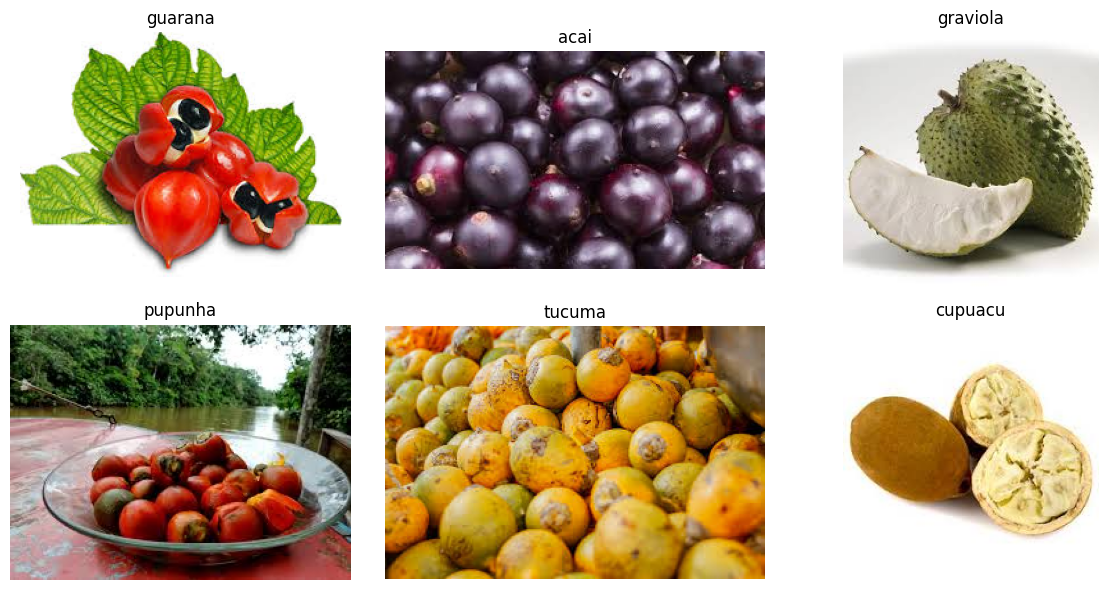

In [6]:
images = []
titles = []

for subdir in base_path.iterdir():
  filenames = os.listdir(subdir)
  filename = random.choice(filenames)
  img_path = subdir / filename

  img = Image.open(img_path)
  images.append(img)
  titles.append(subdir.name)

n = len(images)

plt.figure(figsize=(12, 3 * 2))


for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()

##Check corrupted image and remove

In [7]:
corrupted_paths = []

for subdir in base_path.iterdir():
  filenames = os.listdir(subdir)
  for filename in filenames:
    img_path = subdir / filename

    try:
      with Image.open(img_path) as img:
          img.verify()

    except (IOError, SyntaxError):
      corrupted_paths.append(img_path)
      os.remove(img_path)
      print(f"Removed corrupted image: {img_path}")

print("Number of corrupted images:", len(corrupted_paths))

Number of corrupted images: 0


#Task 2: Data prepocessing with Keras

In [39]:
train_dir = Path("/content/drive/MyDrive/AI - ShlokDhital/FruitinAmazon/train")

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = keras.layers.Rescaling(1./255)

train_ds = keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels='inferred',
  label_mode='int',
  image_size=(img_height, img_width),
  interpolation='nearest',
  batch_size=batch_size,
  shuffle=True,
  validation_split=validation_split,
  subset='training',
  seed=123
)

print(train_ds.class_names)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels='inferred',
  label_mode='int',
  image_size=(img_height, img_width),
  interpolation='nearest',
  batch_size=batch_size,
  shuffle=False,
  validation_split=validation_split,
  subset='validation',
  seed=123
)

print(val_ds.class_names)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Found 90 files belonging to 6 classes.
Using 18 files for validation.
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


# Task 3: Implement CNN

In [9]:
class_num = 6

model = keras.Sequential([
  layers.Conv2D(32, (3, 3), strides=(1,1), padding="same", activation="relu", input_shape=(img_height, img_width, 3)),
  layers.MaxPooling2D((2, 2), strides=(2,2)),
  layers.Conv2D(32, (3, 3), strides=(1,1), padding="same", activation="relu"),
  layers.MaxPooling2D((2, 2), strides=(2,2)),
  layers.Flatten(),
  layers.Dense(64, activation="relu"),
  layers.Dense(128, activation="relu"),
  layers.Dense(class_num, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Compile and train the model

##Compile

In [10]:
model.compile(
    optimizer='Adam',
    loss='sparse_categorical_crossentropy',
    metrics= ['accuracy']
)

##Train

In [33]:
batch_size_fit = 16
epochs = 250

checkpoint_cb = ModelCheckpoint(
    "highest_accuracy.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    batch_size=batch_size_fit,
    callbacks=[checkpoint_cb, earlystop_cb]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 1.0000 - loss: 1.1078e-04
Epoch 1: val_accuracy improved from None to 0.88889, saving model to highest_accuracy.h5



Epoch 1: finished saving model to highest_accuracy.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 586ms/step - accuracy: 1.0000 - loss: 9.3502e-05 - val_accuracy: 0.8889 - val_loss: 0.3245
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 1.0000 - loss: 9.0645e-05
Epoch 2: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 560ms/step - accuracy: 1.0000 - loss: 9.1450e-05 - val_accuracy: 0.8889 - val_loss: 0.3291
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 1.0000 - loss: 9.1774e-05
Epoch 3: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 482ms/step - accuracy: 1.0000 - loss: 9.0046e-05 - val_accuracy: 0.8889 - val_loss: 0.3306
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 1.0000 - loss: 8.0604e-05
Epoch 4: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 494ms/step - accuracy: 1.0000 - loss: 8.8399e-05 - val_accuracy: 0.8889 - val_loss: 0.3285
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/ste

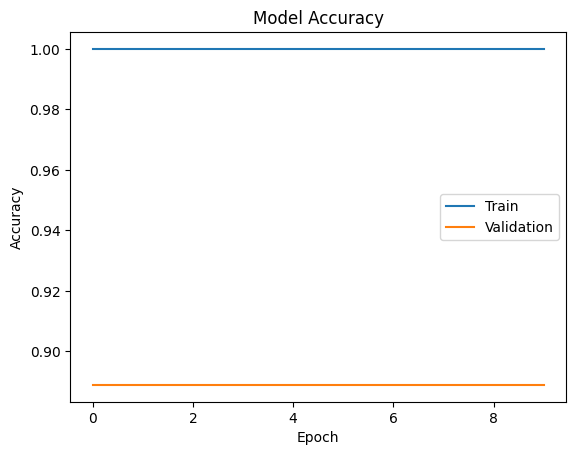

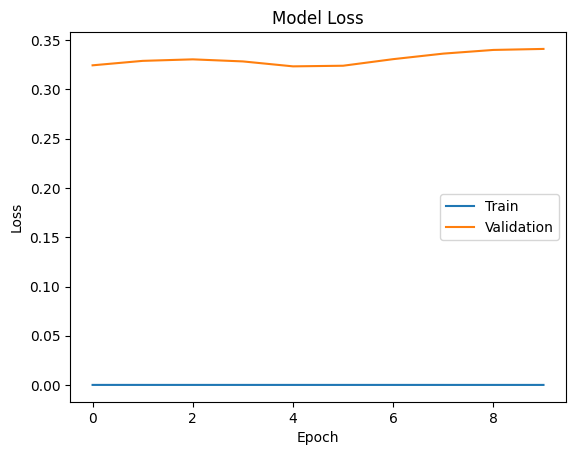

In [65]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

#Task 5: Evaluate the model

In [40]:
test_ds = Path("/content/drive/MyDrive/AI - ShlokDhital/FruitinAmazon/test")

test_ds = keras.preprocessing.image_dataset_from_directory(
    test_ds,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

model.evaluate(test_ds)

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.7333 - loss: 1.0162


[1.0161757469177246, 0.7333333492279053]

#Task 6: Save the model

In [41]:
model.save('Final_model.keras')

In [42]:
loaded_model = keras.models.load_model("/content/highest_accuracy.h5")

In [43]:
loaded_model.evaluate(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 879ms/step - accuracy: 0.7333 - loss: 1.0122


[1.0122023820877075, 0.7333333492279053]

# Task 7: Making Predictions

In [60]:
class_names = ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
y_true = np.concatenate([y for x, y in test_ds], axis=0)

preds = loaded_model.predict(test_ds)
y_pred = np.argmax(preds,axis=1)

pred_classes = [class_names[arg] for arg in y_pred]

print(y_true)
print(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 680ms/step
[0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 3 3 3 3 3 4 4 4 4 4 5 5 5 5 5]
[0 1 0 0 0 1 1 2 1 1 2 2 2 2 2 3 3 3 3 0 4 5 3 4 4 5 1 0 5 0]


In [61]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

        acai       0.57      0.80      0.67         5
     cupuacu       0.67      0.80      0.73         5
    graviola       0.83      1.00      0.91         5
     guarana       0.80      0.80      0.80         5
     pupunha       1.00      0.60      0.75         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.73        30
   macro avg       0.76      0.73      0.73        30
weighted avg       0.76      0.73      0.73        30



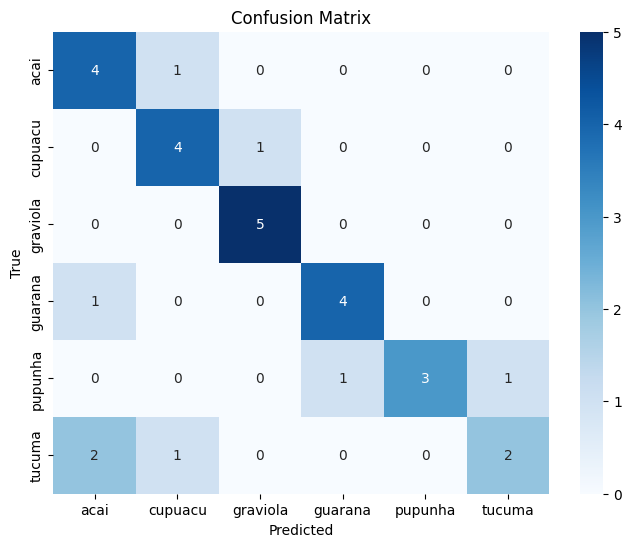

In [64]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()